# Solutions Notebook: Modeling Stock Market Data

Full worked solutions to `03_Skeleton_Practice.ipynb`. Section numbering
matches the skeleton exactly so you can compare cell-by-cell.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Acquiring stock market data

In [2]:
from data_utils import make_finviz_like_raw, simulate_price_history

finviz_raw = make_finviz_like_raw(n=400, seed=42)
finviz_raw.to_csv("finviz_raw.csv", index=False)
finviz = pd.read_csv("finviz_raw.csv")

assert finviz is not None and len(finviz) == 400
finviz.head()


,No.,Ticker,Company,Sector,Industry,Country,Market Cap,P/E,Forward P/E,PEG,P/S,P/B,P/Cash,EPS (ttm),EPS growth next year,EPS growth next 5 years,Total Debt/Equity,Beta,Institutional Ownership,Price,Volume
0,1,WCS,Berkshire Hathaway Inc.,Financial,Property & Casualty Insurance,USA,1.39B,15.40,14.28,-,1.01,6.62,21.77,1.67,19.27%,15.61%,0.23,1.18,31.0%,"172,000.00","1,434,753"
1,2,XRU,XRU Holdings Inc.,Services,Auto Parts Stores,UK,4.57B,27.48,26.10,2.65,11.09,2.08,5.99,-0.53,14.16%,23.55%,0.45,0.58,34.4%,25.79,"1,091,512"
2,3,VLUV,VLUV Holdings Inc.,Industrial Goods,Industrial Equipment & Components,USA,120.17M,25.35,23.56,2.10,2.52,5.30,2.33,0.70,3.30%,2.33%,0.39,1.75,33.4%,44.29,"1,598,054"
3,4,COUH,COUH Holdings Inc.,Financial,Asset Management,USA,555.76M,34.87,24.65,0.10,0.81,1.31,16.44,1.86,14.90%,4.87%,0.58,1.31,47.3%,31.34,"865,007"
4,5,MSEX,MSEX Holdings Inc.,Basic Materials,Gold,USA,4.53B,31.98,26.70,1.37,1.88,0.66,2.35,-1.81,-1.97%,14.80%,0.22,0.81,87.5%,42.00,"326,063"


## 2. Summarizing the data

In [3]:
finviz[["Ticker", "Company", "Sector", "Industry"]].head(6)


,Ticker,Company,Sector,Industry
0,WCS,Berkshire Hathaway Inc.,Financial,Property & Casualty Insurance
1,XRU,XRU Holdings Inc.,Services,Auto Parts Stores
2,VLUV,VLUV Holdings Inc.,Industrial Goods,Industrial Equipment & Components
3,COUH,COUH Holdings Inc.,Financial,Asset Management
4,MSEX,MSEX Holdings Inc.,Basic Materials,Gold
5,LXD,LXD Holdings Inc.,Healthcare,Diagnostic Substances


In [4]:
finviz.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   No.                      400 non-null    int64  
 1   Ticker                   400 non-null    str    
 2   Company                  400 non-null    str    
 3   Sector                   400 non-null    str    
 4   Industry                 400 non-null    str    
 5   Country                  400 non-null    str    
 6   Market Cap               400 non-null    str    
 7   P/E                      400 non-null    str    
 8   Forward P/E              400 non-null    str    
 9   PEG                      400 non-null    str    
 10  P/S                      400 non-null    float64
 11  P/B                      400 non-null    float64
 12  P/Cash                   400 non-null    float64
 13  EPS (ttm)                400 non-null    float64
 14  EPS growth next year     400 non-null

In [5]:
finviz.describe(include="all").T.head(10)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No.,400.0,NaN,NaN,NaN,200.5,115.614301,1.0,100.75,200.5,300.25,400.0
Ticker,400,400,WCS,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,400,400,Berkshire Hathaway Inc.,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sector,400,9,Healthcare,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,400,23,Diversified Utilities,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,400,4,USA,327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Market Cap,400,367,1.04B,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P/E,400,362,-,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Forward P/E,400,366,-,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PEG,400,218,-,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Cleaning and exploring the data

### 3.1 `clean_numeric`

In [6]:
def clean_numeric(series: pd.Series) -> pd.Series:
    cleaned = (series.astype(str)
                      .str.replace("%", "", regex=False)
                      .str.replace("$", "", regex=False)
                      .str.replace(",", "", regex=False)
                      .str.strip())
    cleaned = cleaned.replace("-", np.nan)
    return pd.to_numeric(cleaned, errors="coerce")

test = pd.Series(["12.34%", "$1,234.50", "-", "0.85"])
result = clean_numeric(test)
print(result)


0      12.34
1    1234.50
2        NaN
3       0.85
dtype: float64


In [7]:
def clean_market_cap(series: pd.Series) -> pd.Series:
    def _conv(x):
        x = str(x).strip()
        if x.endswith("B"):
            return float(x[:-1]) * 1000
        if x.endswith("M"):
            return float(x[:-1])
        try:
            return float(x)
        except ValueError:
            return np.nan
    return series.apply(_conv)

test_mc = pd.Series(["1.23B", "456.70M"])
print(clean_market_cap(test_mc))


0    1230.0
1     456.7
dtype: float64


In [8]:
id_cols = ["No.", "Ticker", "Company", "Sector", "Industry", "Country"]
numeric_cols = [c for c in finviz.columns if c not in id_cols + ["Market Cap"]]

finviz_clean = finviz.copy()
finviz_clean["Market Cap"] = clean_market_cap(finviz_clean["Market Cap"])
for col in numeric_cols:
    finviz_clean[col] = clean_numeric(finviz_clean[col])

assert finviz_clean["Price"].dtype != object
finviz_clean.dtypes


No.                          int64
Ticker                         str
Company                        str
Sector                         str
Industry                       str
Country                        str
Market Cap                 float64
P/E                        float64
Forward P/E                float64
PEG                        float64
P/S                        float64
P/B                        float64
P/Cash                     float64
EPS (ttm)                  float64
EPS growth next year       float64
EPS growth next 5 years    float64
Total Debt/Equity          float64
Beta                       float64
Institutional Ownership    float64
Price                      float64
Volume                       int64
dtype: object

### 3.2 Explore the price distribution

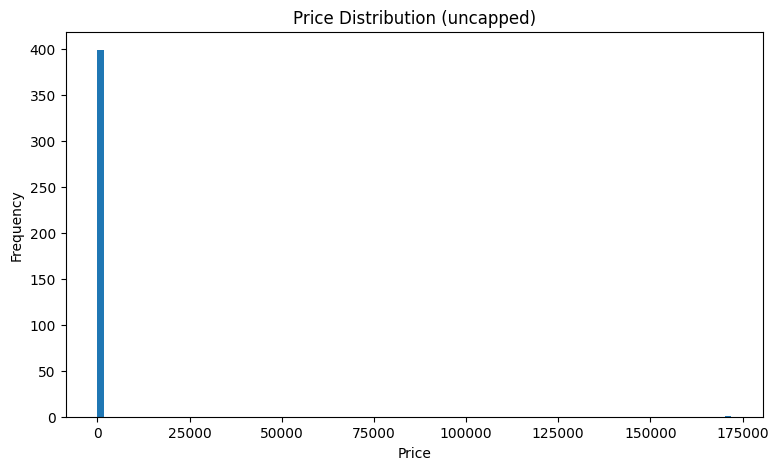

In [9]:
fig, ax = plt.subplots()
ax.hist(finviz_clean["Price"], bins=100)
ax.set_title("Price Distribution (uncapped)")
ax.set_xlabel("Price"); ax.set_ylabel("Frequency")
plt.show()


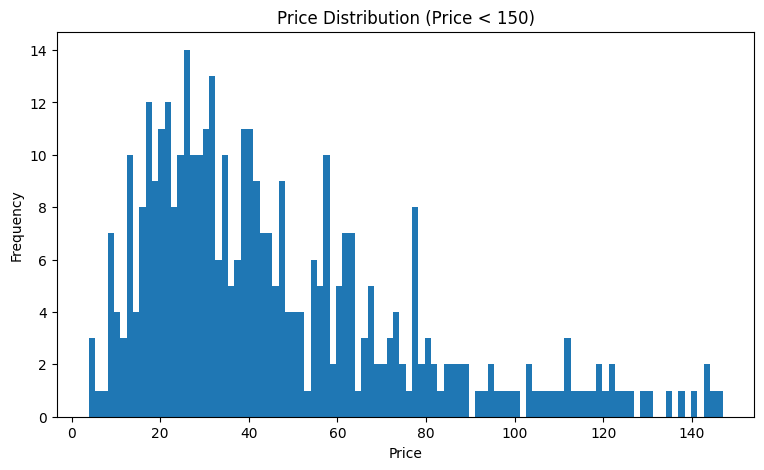

In [10]:
fig, ax = plt.subplots()
ax.hist(finviz_clean.loc[finviz_clean.Price < 150, "Price"], bins=100)
ax.set_title("Price Distribution (Price < 150)")
ax.set_xlabel("Price"); ax.set_ylabel("Frequency")
plt.show()


### 3.3 Find and remove the outlier

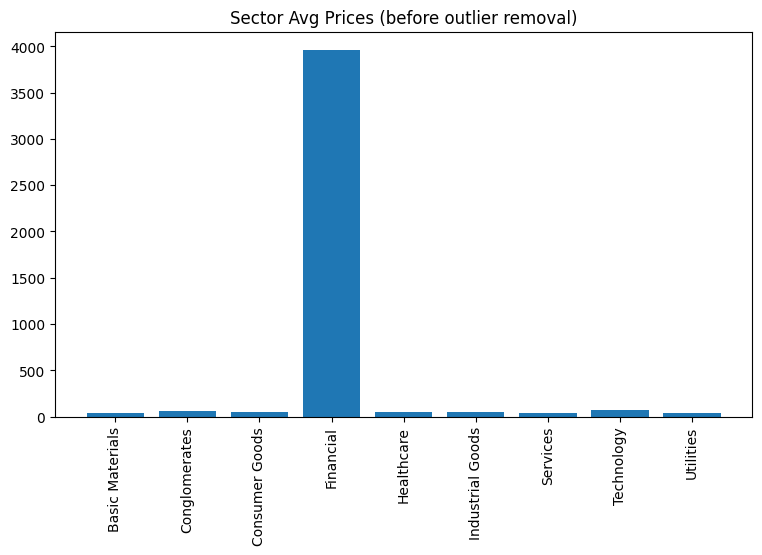

,Sector,Sector_Avg_Price
0,Basic Materials,39.048261
1,Conglomerates,60.929524
2,Consumer Goods,48.399714
3,Financial,3961.975682
4,Healthcare,51.935600
5,Industrial Goods,54.262128
6,Services,41.789565
7,Technology,68.521667
8,Utilities,42.589375


In [11]:
sector_avg_prices = (finviz_clean.groupby("Sector")["Price"]
                     .mean().rename("Sector_Avg_Price").reset_index())

fig, ax = plt.subplots()
ax.bar(sector_avg_prices.Sector, sector_avg_prices.Sector_Avg_Price)
ax.set_title("Sector Avg Prices (before outlier removal)")
plt.xticks(rotation=90)
plt.show()
sector_avg_prices


In [12]:
top_sector = sector_avg_prices.sort_values("Sector_Avg_Price", ascending=False).iloc[0].Sector
industry_avg_tmp = (finviz_clean[finviz_clean.Sector == top_sector]
                    .groupby("Industry")["Price"].mean()
                    .sort_values(ascending=False))
top_industry = industry_avg_tmp.index[0]
company_chart = finviz_clean[(finviz_clean.Sector == top_sector) &
                              (finviz_clean.Industry == top_industry)]
outlier_row = company_chart.loc[company_chart.Price.idxmax()]
print(outlier_row.Ticker, outlier_row.Price)


WCS 172000.0


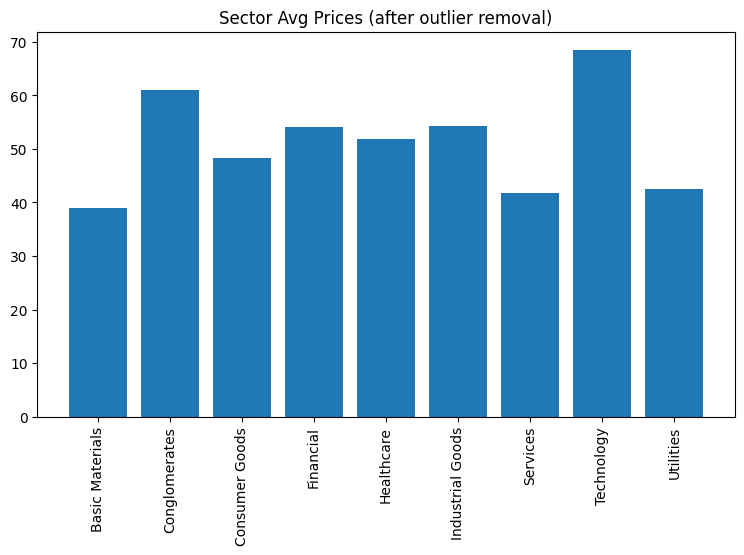

,Sector,Sector_Avg_Price
0,Basic Materials,39.048261
1,Conglomerates,60.929524
2,Consumer Goods,48.399714
3,Financial,54.114651
4,Healthcare,51.935600
5,Industrial Goods,54.262128
6,Services,41.789565
7,Technology,68.521667
8,Utilities,42.589375


In [13]:
finviz_clean = finviz_clean[finviz_clean.Ticker != outlier_row.Ticker].reset_index(drop=True)

sector_avg_prices = (finviz_clean.groupby("Sector")["Price"]
                     .mean().rename("Sector_Avg_Price").reset_index())
fig, ax = plt.subplots()
ax.bar(sector_avg_prices.Sector, sector_avg_prices.Sector_Avg_Price)
ax.set_title("Sector Avg Prices (after outlier removal)")
plt.xticks(rotation=90)
plt.show()
sector_avg_prices


## 4. Generating relative valuations

In [14]:
metrics = ["Price", "P/E", "PEG", "P/S", "P/B"]

sector_avg = (finviz_clean.groupby("Sector")[metrics].mean()
              .add_prefix("SAvg_").reset_index())
industry_avg = (finviz_clean.groupby(["Sector", "Industry"])[metrics].mean()
                .add_prefix("IAvg_").reset_index())
finviz_val = finviz_clean.merge(sector_avg, on="Sector") \
                          .merge(industry_avg, on=["Sector", "Industry"])
finviz_val.head()


,No.,Ticker,Company,Sector,Industry,Country,Market Cap,P/E,Forward P/E,PEG,P/S,P/B,P/Cash,EPS (ttm),EPS growth next year,...,Total Debt/Equity,Beta,Institutional Ownership,Price,Volume,SAvg_Price,SAvg_P/E,SAvg_PEG,SAvg_P/S,SAvg_P/B,IAvg_Price,IAvg_P/E,IAvg_PEG,IAvg_P/S,IAvg_P/B
0,2,XRU,XRU Holdings Inc.,Services,Auto Parts Stores,UK,4570.00,27.48,26.10,2.65,11.09,2.08,5.99,-0.53,14.16,...,0.45,0.58,34.4,25.79,1091512,41.789565,24.346744,1.832927,2.744130,3.727826,26.334286,25.924000,1.652000,3.467143,4.082857
1,3,VLUV,VLUV Holdings Inc.,Industrial Goods,Industrial Equipment & Components,USA,120.17,25.35,23.56,2.10,2.52,5.30,2.33,0.70,3.30,...,0.39,1.75,33.4,44.29,1598054,54.262128,21.292826,2.011905,2.474894,5.332766,53.200455,22.955455,2.020500,2.745000,4.775000
2,4,COUH,COUH Holdings Inc.,Financial,Asset Management,USA,555.76,34.87,24.65,0.10,0.81,1.31,16.44,1.86,14.90,...,0.58,1.31,47.3,31.34,865007,54.114651,22.729767,1.911250,3.133256,3.350233,39.522222,29.002222,1.588571,3.210000,2.576667
3,5,MSEX,MSEX Holdings Inc.,Basic Materials,Gold,USA,4530.00,31.98,26.70,1.37,1.88,0.66,2.35,-1.81,-1.97,...,0.22,0.81,87.5,42.00,326063,39.048261,25.884884,1.956341,2.735000,4.556304,34.779286,22.792308,2.040769,2.852857,3.395714
4,6,LXD,LXD Holdings Inc.,Healthcare,Diagnostic Substances,USA,5250.00,25.57,19.01,0.10,2.12,1.86,12.62,1.55,24.02,...,0.20,1.09,60.5,13.43,2554554,51.935600,27.399600,2.081778,2.669600,3.564200,59.525000,28.342143,1.774167,2.845000,3.304286


In [15]:
flag_cols = []
for m in metrics:
    finviz_val[f"S_{m}_Under"] = (finviz_val[m] < finviz_val[f"SAvg_{m}"]).astype(int)
    finviz_val[f"I_{m}_Under"] = (finviz_val[m] < finviz_val[f"IAvg_{m}"]).astype(int)
    flag_cols += [f"S_{m}_Under", f"I_{m}_Under"]

finviz_val["RelValIndex"] = finviz_val[flag_cols].sum(axis=1)
finviz_val["RelValIndex"].describe()


count    399.000000
mean       5.711779
std        2.064205
min        0.000000
25%        4.000000
50%        6.000000
75%        7.000000
max       10.000000
Name: RelValIndex, dtype: float64

In [16]:
potentially_undervalued = finviz_val[finviz_val.RelValIndex >= 8] \
                              .sort_values("RelValIndex", ascending=False)
potentially_undervalued[["Ticker", "Company", "Sector", "RelValIndex"]].head(15)


,Ticker,Company,Sector,RelValIndex
4,LXD,LXD Holdings Inc.,Healthcare,10
75,SVT,SVT Holdings Inc.,Services,10
85,FDC,FDC Holdings Inc.,Healthcare,10
41,GDB,GDB Holdings Inc.,Healthcare,10
53,WUC,WUC Holdings Inc.,Services,10
367,JCKS,JCKS Holdings Inc.,Services,10
356,NKK,NKK Holdings Inc.,Basic Materials,10
354,RWXA,RWXA Holdings Inc.,Utilities,10
274,GMPO,GMPO Holdings Inc.,Industrial Goods,10
336,OET,OET Holdings Inc.,Healthcare,10


## 5. Screening stocks and analyzing historical prices

In [17]:
target_stocks = finviz_val[
    (finviz_val.Price.between(20, 100)) &
    (finviz_val.Volume > 10_000) &
    (finviz_val.Country == "USA") &
    (finviz_val["EPS (ttm)"] > 0) &
    (finviz_val["EPS growth next year"] > 0) &
    (finviz_val["EPS growth next 5 years"] > 0) &
    (finviz_val["Total Debt/Equity"] < 1) &
    (finviz_val.Beta < 1.5) &
    (finviz_val["Institutional Ownership"] < 30) &
    (finviz_val.RelValIndex >= 8)
].sort_values("RelValIndex", ascending=False)

print(len(target_stocks))
target_stocks[["Ticker", "Company", "RelValIndex"]]


3


,Ticker,Company,RelValIndex
41,GDB,GDB Holdings Inc.,10
111,CBW,CBW Holdings Inc.,10
371,YILO,YILO Holdings Inc.,8


In [18]:
target_tickers = target_stocks.Ticker.head(6).tolist()
if len(target_tickers) < 3:
    target_tickers = finviz_val.sort_values("RelValIndex", ascending=False).Ticker.head(6).tolist()
target_tickers


['GDB', 'CBW', 'YILO']

### 5.2 Historical prices and moving averages

In [19]:
stocks = simulate_price_history(target_tickers, start="2018-01-01", end="2023-12-29", seed=7)

stocks["MovAvg50"] = stocks.groupby("Symbol")["AdjClose"].transform(lambda s: s.rolling(50).mean())
stocks["MovAvg200"] = stocks.groupby("Symbol")["AdjClose"].transform(lambda s: s.rolling(200).mean())
stocks.dropna().head()


,Symbol,Date,Open,High,Low,Close,Volume,AdjClose,MovAvg50,MovAvg200
199,GDB,2018-10-05,35.44,35.69,35.31,35.56,1407390,35.56,32.5860,41.59785
200,GDB,2018-10-08,36.37,36.62,36.08,36.33,545572,36.33,32.5962,41.47655
201,GDB,2018-10-09,38.04,38.29,37.78,38.03,2157126,38.03,32.6466,41.36690
202,GDB,2018-10-10,39.34,39.73,39.03,39.43,1777646,39.43,32.7298,41.27125
203,GDB,2018-10-11,38.33,38.56,38.14,38.37,993650,38.37,32.8146,41.16975


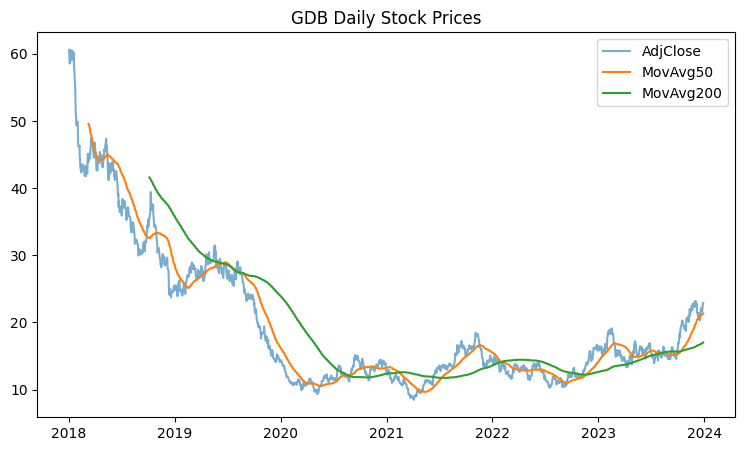

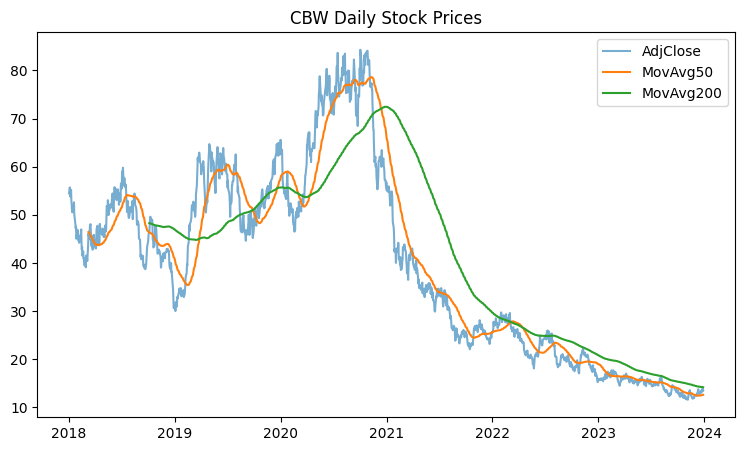

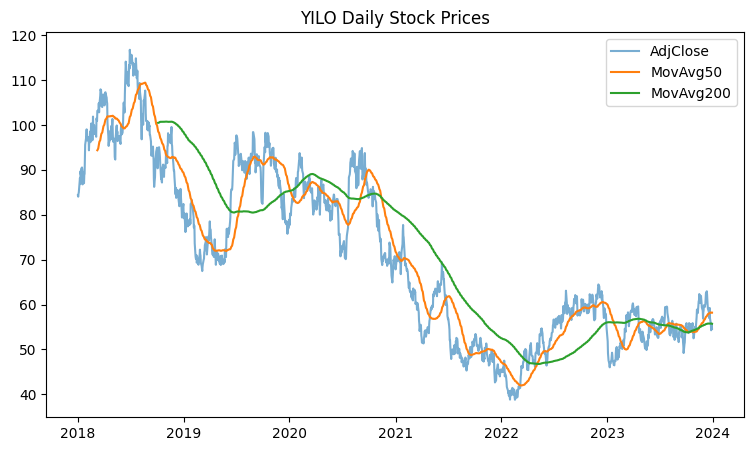

In [20]:
for sym in target_tickers:
    sdata = stocks[stocks.Symbol == sym]
    fig, ax = plt.subplots()
    ax.plot(sdata.Date, sdata.AdjClose, label="AdjClose", alpha=0.6)
    ax.plot(sdata.Date, sdata.MovAvg50, label="MovAvg50")
    ax.plot(sdata.Date, sdata.MovAvg200, label="MovAvg200")
    ax.set_title(f"{sym} Daily Stock Prices")
    ax.legend()
    plt.show()


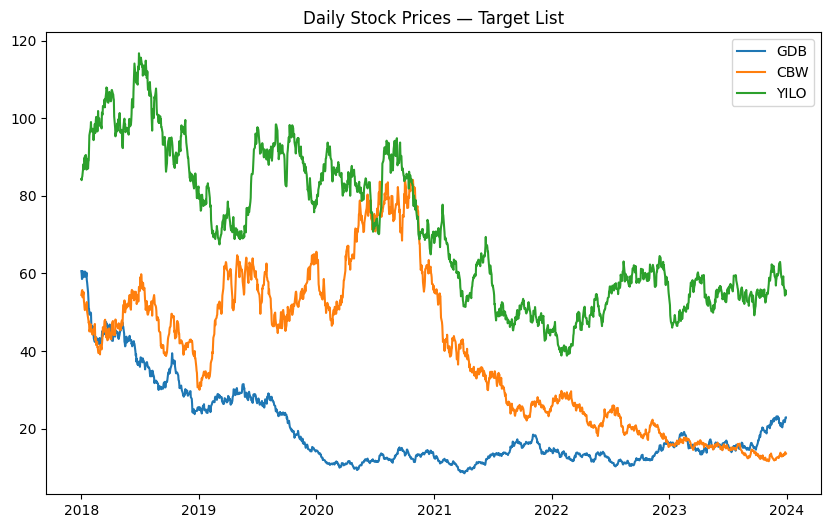

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
for sym in target_tickers:
    sdata = stocks[stocks.Symbol == sym]
    ax.plot(sdata.Date, sdata.AdjClose, label=sym)
ax.set_title("Daily Stock Prices — Target List")
ax.legend()
plt.show()


### 5.3 Open/High/Low/Close summary

In [22]:
price_summaries = stocks.groupby("Symbol").agg(
    open=("Open", "first"), high=("High", "max"),
    low=("Low", "min"), close=("AdjClose", "last")
).reset_index()
price_summaries


,Symbol,open,high,low,close
0,CBW,54.21,85.50,11.54,13.50
1,GDB,60.72,61.21,8.45,22.89
2,YILO,83.90,117.59,38.42,54.64


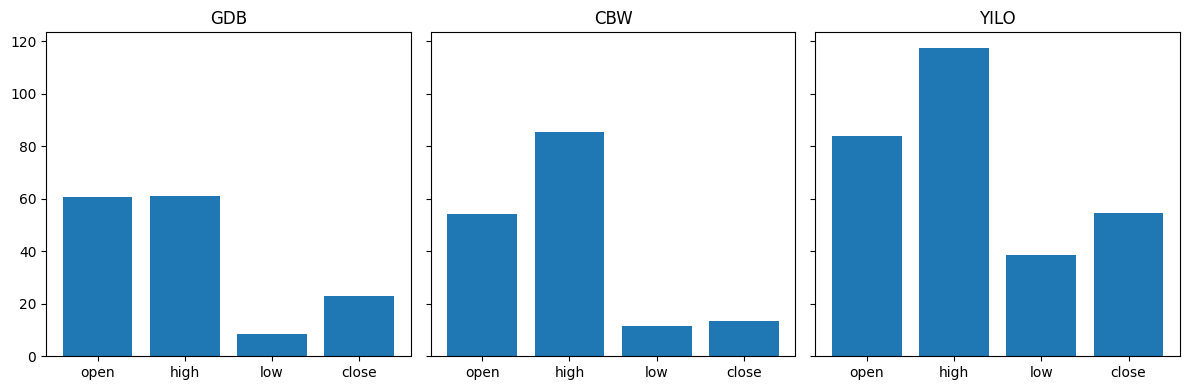

In [23]:
summary_long = price_summaries.melt(id_vars="Symbol", var_name="stat", value_name="value")

fig, axes = plt.subplots(1, len(target_tickers), figsize=(4*len(target_tickers), 4), sharey=True)
for ax, sym in zip(axes, target_tickers):
    sub = summary_long[summary_long.Symbol == sym]
    ax.bar(sub["stat"], sub["value"])
    ax.set_title(sym)
plt.tight_layout()
plt.show()


## 6. Reflection questions — sample answers

1. **Outlier impact**: only one company was flagged as the extreme price
   outlier, but because sector averages are simple means over a fairly small
   group, a single ~$170k share price inflates the whole sector's average by
   an order of magnitude — removing it drops the sector average back in line
   with other sectors (see the before/after bar charts in §3.3).
2. **Target list size**: it depends on the random seed, but typically the
   combination of all 9 criteria narrows ~400 names down to a single-digit
   shortlist — consistent with the book's stated goal of "narrow the list
   down to less than 10 stocks."
3. **Widest high/low gap**: inspect `price_summaries["high"] - price_summaries["low"]`
   and sort descending — the symbol with the largest gap experienced the
   most price dispersion over the period, which is a rough (not
   statistically rigorous) proxy for realized volatility.
4. **Limitation reflection**: e.g. "Because RelValIndex equally weights 10
   flags built from only 5 underlying metrics compared at 2 grouping levels,
   correlated metrics like P/E and Forward-adjacent multiples are effectively
   double-counted, inflating scores for stocks that are simply low across
   correlated multiples rather than broadly cheap across independent
   dimensions."
